# Embedding Simple RNN

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
docs = ['go india',
		'india india',
		'hip hip hurray',
		'jeetega bhai jeetega india jeetega',
		'bharat mata ki jai',
		'kohli kohli',
		'sachin sachin',
		'dhoni dhoni',
		'modi ji ki jai',
		'inquilab zindabad']

In [3]:
vectorize_layer = keras.layers.TextVectorization()

In [4]:
vectorize_layer.adapt(docs)

In [5]:
docs

['go india',
 'india india',
 'hip hip hurray',
 'jeetega bhai jeetega india jeetega',
 'bharat mata ki jai',
 'kohli kohli',
 'sachin sachin',
 'dhoni dhoni',
 'modi ji ki jai',
 'inquilab zindabad']

In [6]:
sequences = vectorize_layer(docs)

In [7]:
sequences

<tf.Tensor: shape=(10, 5), dtype=int64, numpy=
array([[16,  2,  0,  0,  0],
       [ 2,  2,  0,  0,  0],
       [ 8,  8, 15,  0,  0],
       [ 3, 18,  3,  2,  3],
       [17, 12,  6,  7,  0],
       [ 5,  5,  0,  0,  0],
       [ 4,  4,  0,  0,  0],
       [ 9,  9,  0,  0,  0],
       [11, 13,  6,  7,  0],
       [14, 10,  0,  0,  0]])>

In [8]:
(X_train,y_train), (X_test,y_test) = keras.datasets.imdb.load_data()

In [9]:
X_train.shape

(25000,)

In [10]:
y_train.shape

(25000,)

In [11]:
len(X_train[0])

218

In [12]:
X_train=keras.preprocessing.sequence.pad_sequences(X_train)
X_test=keras.preprocessing.sequence.pad_sequences(X_test)

In [17]:
model = keras.Sequential([
    keras.layers.Input(shape=(218,)),
    keras.layers.Embedding(input_dim=10000,output_dim=2),
    keras.layers.SimpleRNN(units=32),
    keras.layers.Dense(units=1, activation='sigmoid')
])

In [18]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 218, 2)         │        20,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,153 (82.63 KB)

 Trainable params: 21,153 (82.63 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [20]:
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test,y_test), batch_size=512)

Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 316ms/step - accuracy: 0.5119 - loss: 0.6934 - val_accuracy: 0.5464 - val_loss: 0.6895
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 216ms/step - accuracy: 0.5964 - loss: 0.6798 - val_accuracy: 0.5609 - val_loss: 0.6714
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 215ms/step - accuracy: 0.6791 - loss: 0.6407 - val_accuracy: 0.7537 - val_loss: 0.5589
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.7963 - loss: 0.5031 - val_accuracy: 0.8087 - val_loss: 0.4415
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 215ms/step - accuracy: 0.8437 - loss: 0.3845 - val_accuracy: 0.8030 - val_loss: 0.4369


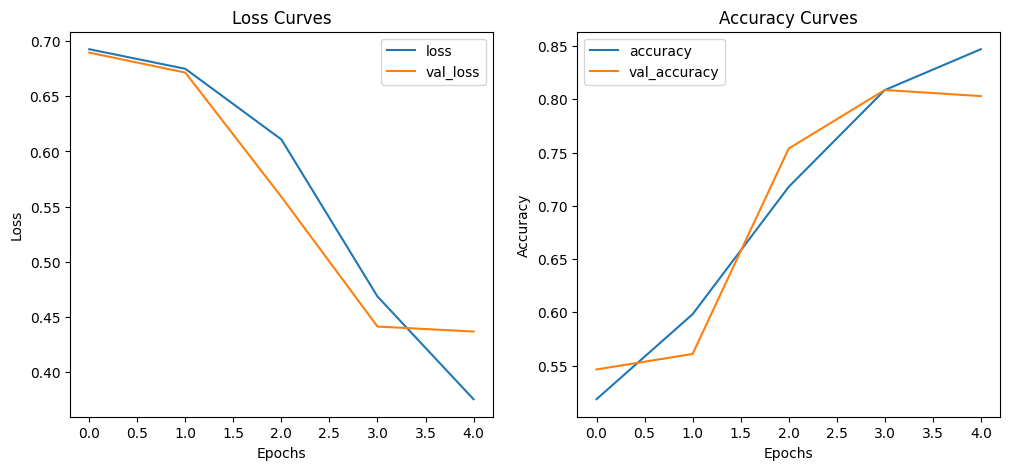

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
